In [1]:

import torch
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure
import numpy as np
import torch
from tqdm import tqdm
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import torchvision.transforms.functional as TF
from tqdm import tqdm
import torch
import os
import os
import torch
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets.folder import default_loader
import torchvision.transforms.functional as TF
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import torchvision.transforms.functional as TF
from torchvision.datasets.folder import default_loader
from tqdm import tqdm
import torch
import torch.nn.functional as F
from PIL import Image
import os
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


c:\Users\ZINGA\Desktop\Master Course\5º First Extension\D.S. Lab II\Chest-X Ray\Supervisor\Dissertation\GANs\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
print("PyTorch versão:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())
print("Quantidade de GPUs:", torch.cuda.device_count())
print("Nome da GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Nenhuma GPU detectada")
print("Memória da GPU:", torch.cuda.mem_get_info() if torch.cuda.is_available() else "N/A")

PyTorch versão: 2.5.1+cu121
CUDA disponível: True
Quantidade de GPUs: 1
Nome da GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Memória da GPU: (3463865959, 4294443008)


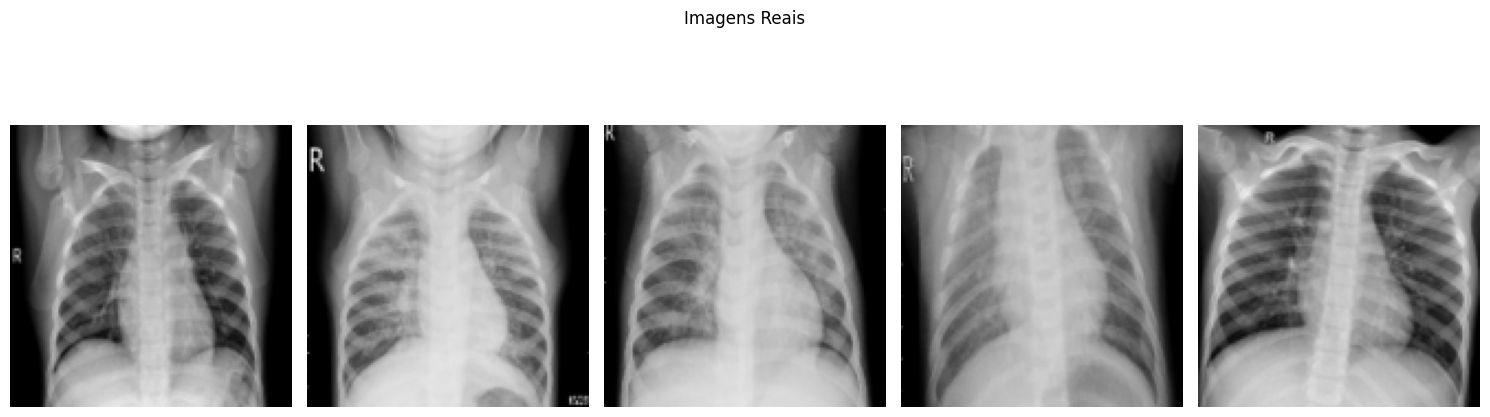

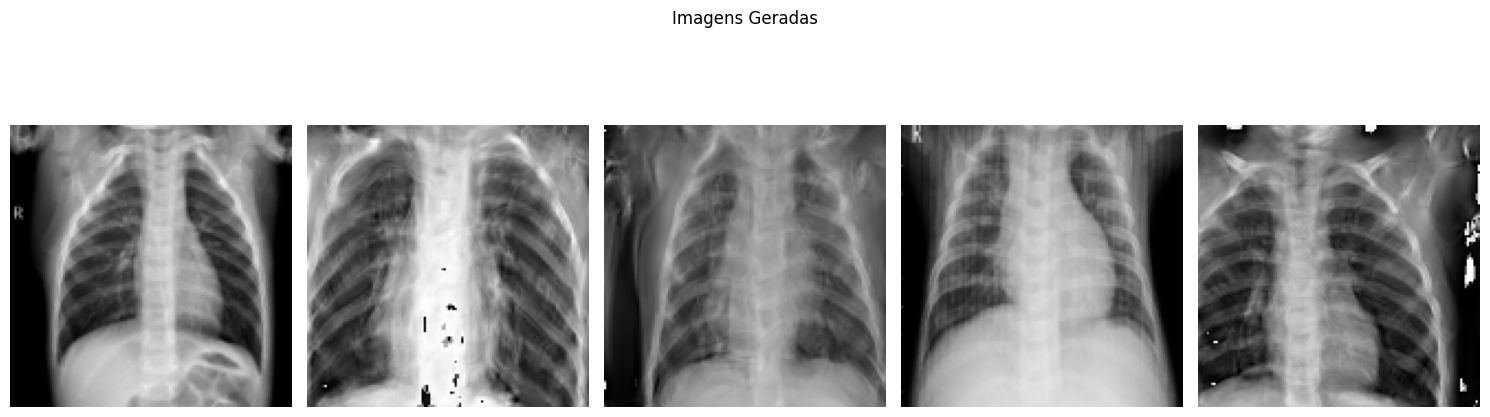

In [3]:

# === CONFIGURAÇÃO ===
batch_size = 8

# Caminhos corrigidos (sem quebra de linha!)
real_path = r"C:\Users\ZINGA\Desktop\Master Course\5º First Extension\D.S. Lab II\Chest-X Ray\Supervisor\Dissertation\GANs\DDPM_X-Ray-main.21.02.2025\Dataset\Balanced_data1\Greedy_K_Selection\Original\selected_images"

fake_path = r"C:\Users\ZINGA\Desktop\Master Course\5º First Extension\D.S. Lab II\Chest-X Ray\Supervisor\Dissertation\GANs\DDPM_X-Ray-main.21.02.2025\Dataset\Balanced_data1\Greedy_K_Selection\Mixed\PGGANS160_Mixed"

# Transformação
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Loaders
real_dataset = datasets.ImageFolder(real_path, transform=transform)
fake_dataset = datasets.ImageFolder(fake_path, transform=transform)

real_loader = DataLoader(real_dataset, batch_size=batch_size, shuffle=True)
fake_loader = DataLoader(fake_dataset, batch_size=batch_size, shuffle=True)

# === PEGAR UM BATCH ===
real_batch, _ = next(iter(real_loader))
fake_batch, _ = next(iter(fake_loader))

# === FUNÇÃO PARA VISUALIZAR ===
def show_images(batch, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i in range(5):
        img = batch[i].permute(1, 2, 0).cpu().numpy()
        axes[i].imshow(img, cmap='gray')
        axes[i].axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# === MOSTRAR ===
show_images(real_batch, "Imagens Reais")
show_images(fake_batch, "Imagens Geradas")



🔎 Avaliando Balanced_data1/Greedy_K_Selection/PGGANS150_Mixed/NORMAL
📸 Total real images: 200
🖼️ Total synthetic images: 404


c:\Users\ZINGA\Desktop\Master Course\5º First Extension\D.S. Lab II\Chest-X Ray\Supervisor\Dissertation\GANs\DDPM_X-Ray-main.21.02.2025\DDPM_X-Ray\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)  # noqa: B028
Fake images: 100%|██████████| 50/50 [00:21<00:00,  2.29it/s]



🔎 Avaliando Balanced_data1/Greedy_K_Selection/PGGANS150_Mixed/PNEUMONIA
📸 Total real images: 200
🖼️ Total synthetic images: 2157


Fake images: 100%|██████████| 269/269 [00:21<00:00, 12.47it/s]



🔎 Avaliando Balanced_data1/Greedy_K_Selection/PGGANS160_Mixed/NORMAL
📸 Total real images: 200
🖼️ Total synthetic images: 2200


...


🔎 Avaliando Imbalanced_data1/Randeom_Selection/PGGANS160_Mixed/NORMAL
📸 Total real images: 1500
🖼️ Total synthetic images: 1500


Fake images: 100%|██████████| 187/187 [00:25<00:00,  7.22it/s]



🔎 Avaliando Imbalanced_data1/Randeom_Selection/PGGANS160_Mixed/PNEUMONIA
📸 Total real images: 200
🖼️ Total synthetic images: 2200


Fake images: 100%|██████████| 275/275 [00:33<00:00,  8.26it/s]



📂 Balanced_data1/Greedy_K_Selection/PGGANS150_Mixed | Classe: NORMAL
✅ FID Score   : 133.1923
✅ KID Mean    : 0.1330
✅ KID Std     : 0.0137
✅ SSIM Score  : 0.3638

📂 Balanced_data1/Greedy_K_Selection/PGGANS150_Mixed | Classe: PNEUMONIA
✅ FID Score   : 182.5891
✅ KID Mean    : 0.1281
✅ KID Std     : 0.0242
✅ SSIM Score  : 0.4776

📂 Balanced_data1/Greedy_K_Selection/PGGANS160_Mixed | Classe: NORMAL
✅ FID Score   : 103.9294
✅ KID Mean    : 0.0951
✅ KID Std     : 0.0129
✅ SSIM Score  : 0.3490

📂 Balanced_data1/Greedy_K_Selection/PGGANS160_Mixed | Classe: PNEUMONIA
✅ FID Score   : 136.0137
✅ KID Mean    : 0.1255
✅ KID Std     : 0.0142
✅ SSIM Score  : 0.4689

📂 Balanced_data1/Randeom_Selection/PGGANS150_Mixed | Classe: NORMAL
✅ FID Score   : 115.7297
✅ KID Mean    : 0.1091
✅ KID Std     : 0.0137
✅ SSIM Score  : 0.3771

📂 Balanced_data1/Randeom_Selection/PGGANS150_Mixed | Classe: PNEUMONIA
✅ FID Score   : 135.0500
✅ KID Mean    : 0.1249
✅ KID Std     : 0.0163
✅ SSIM Score  : 0.5036

📂 Balanc

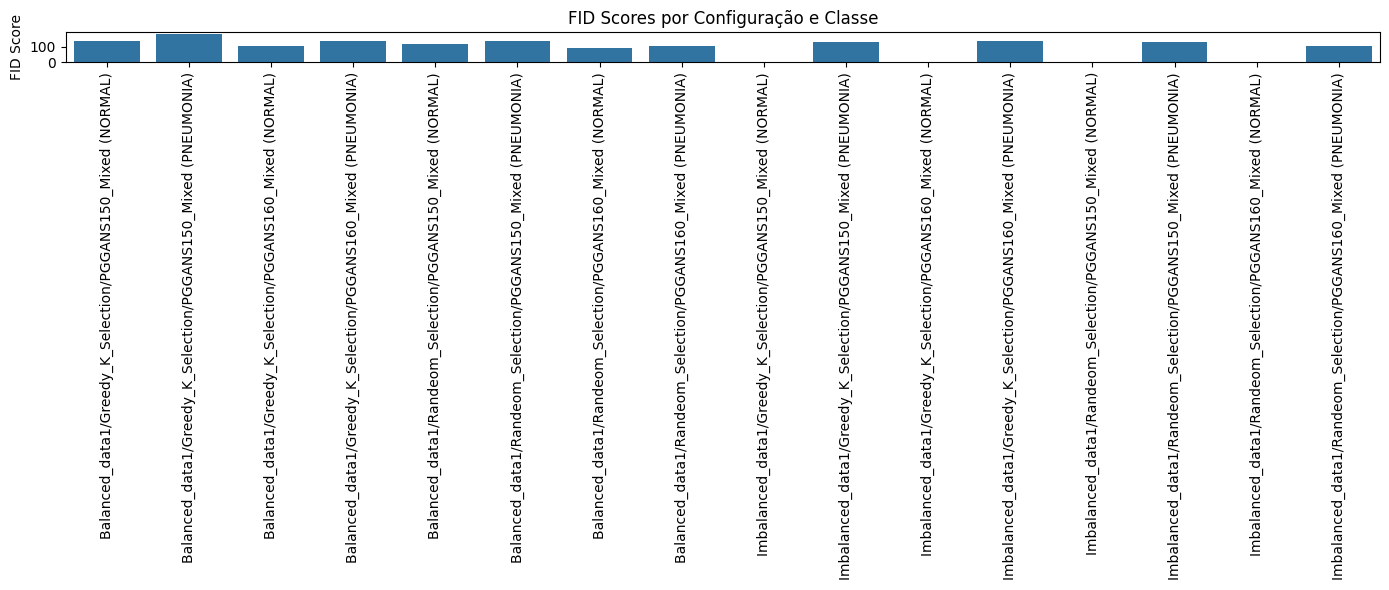

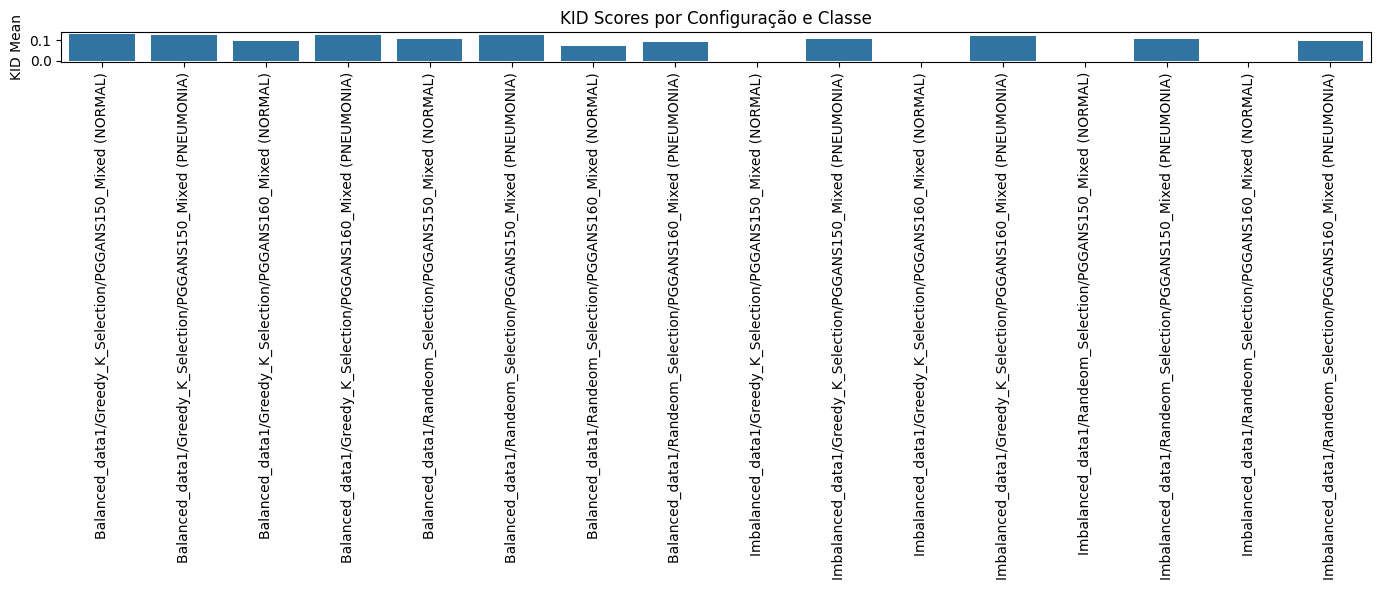

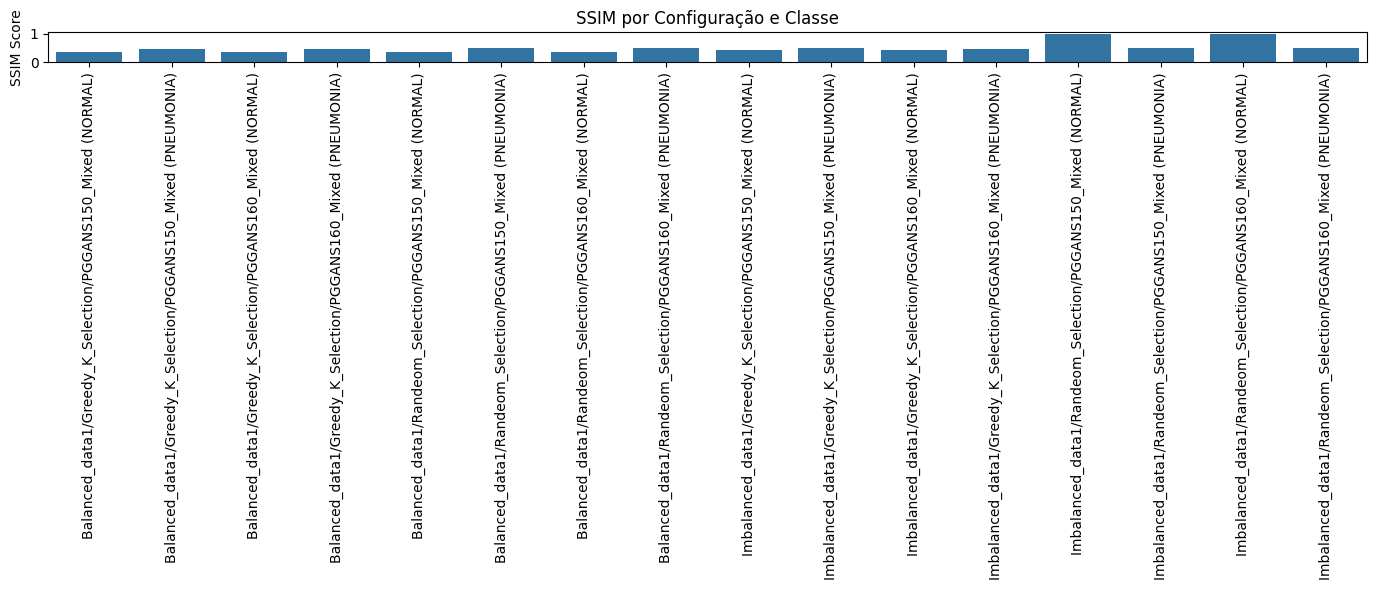

In [4]:
import os
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.datasets.folder import default_loader
import torchvision.transforms.functional as TF
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import gc
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === CONFIGURAÇÃO GERAL ===
base_path = r"C:\Users\ZINGA\Desktop\Master Course\5º First Extension\D.S. Lab II\Chest-X Ray\Supervisor\Dissertation\GANs\DDPM_X-Ray-main.21.02.2025"

configs = [
    ("Balanced_data1", "Greedy_K_Selection"),
    ("Balanced_data1", "Randeom_Selection"),
    ("Imbalanced_data1", "Greedy_K_Selection"),
    ("Imbalanced_data1", "Randeom_Selection"),
]

model_folders = ["PGGANS150_Mixed", "PGGANS160_Mixed"]

batch_size = 8

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
])

# === Dataset customizado ===
class SimpleImageDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.transform = transform
        self.samples = [
            os.path.join(folder_path, fname)
            for fname in os.listdir(folder_path)
            if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]
        self.loader = default_loader

    def __getitem__(self, idx):
        path = self.samples[idx]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, 0

    def __len__(self):
        return len(self.samples)

# === Função para calcular FID e KID ===

def calculate_fid_kid_ssim(real_dir, fake_dir):
    real_dataset = SimpleImageDataset(real_dir, transform)
    fake_dataset = SimpleImageDataset(fake_dir, transform)

    # ✅ Imprimir quantas imagens foram carregadas
    print(f"📸 Total real images: {len(real_dataset)}")
    print(f"🖼️ Total synthetic images: {len(fake_dataset)}")

    real_loader = DataLoader(real_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    fake_loader = DataLoader(fake_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    kid = KernelInceptionDistance(subset_size=50).to(device)
    ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

    ssim_values = []

    # FID/KID: processar todos
    for real_images, _ in tqdm(real_loader, desc="Real images"):
        real_images = (real_images * 255).clamp(0, 255).to(torch.uint8).to(device)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)

    for fake_images, _ in tqdm(fake_loader, desc="Fake images"):
        fake_images = (fake_images * 255).clamp(0, 255).to(torch.uint8).to(device)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)

    # SSIM: apenas imagens pareadas (1:1) — usar zip manual limitado ao menor tamanho
    real_iter = iter(DataLoader(real_dataset, batch_size=batch_size, shuffle=False, drop_last=True))
    fake_iter = iter(DataLoader(fake_dataset, batch_size=batch_size, shuffle=False, drop_last=True))

    for _ in range(min(len(real_loader), len(fake_loader))):
        real_images, _ = next(real_iter)
        fake_images, _ = next(fake_iter)
        real_images = (real_images * 255).clamp(0, 255).to(torch.uint8).to(device)
        fake_images = (fake_images * 255).clamp(0, 255).to(torch.uint8).to(device)
        ssim_score = ssim_metric(fake_images.float()/255.0, real_images.float()/255.0)
        ssim_values.append(ssim_score.item())

    fid_value = fid.compute().item()
    kid_mean, kid_std = kid.compute()
    ssim_mean = sum(ssim_values) / len(ssim_values)

    return fid_value, kid_mean.item(), kid_std.item(), ssim_mean



# === Execução em todas configurações ===
# === Execução em todas configurações (AJUSTADO) ===
results = []

for data_type, selection_type in configs:
    for model_folder in model_folders:
        for class_name in ["NORMAL", "PNEUMONIA"]:
            if data_type == "Balanced_data1" and selection_type == "Greedy_K_Selection":
                real_path = os.path.join(base_path, "Dataset", data_type, selection_type,
                                         "Original", "selected_images", class_name)
            elif data_type == "Balanced_data1" and selection_type == "Randeom_Selection":
                real_path = os.path.join(base_path, "Dataset", data_type, selection_type,
                                         "Original_Random", class_name)
            else: # Para Imbalanced_data (não tem selected_images)
                real_path = os.path.join(base_path, "Dataset", data_type, selection_type,
                                         "Original", class_name)

            fake_path = os.path.join(base_path, "Dataset", data_type, selection_type,
                                     "Mixed", model_folder, class_name)

            if not os.path.isdir(real_path) or not os.path.isdir(fake_path):
                print(f"❌ Pasta não encontrada: {real_path} ou {fake_path}")
                continue

            print(f"\n🔎 Avaliando {data_type}/{selection_type}/{model_folder}/{class_name}")
            #fid, kid_mean, kid_std = calculate_fid_kid_ssim(real_path, fake_path)
            fid, kid_mean, kid_std, ssim = calculate_fid_kid_ssim(real_path, fake_path)


            results.append({
                  "configuração": f"{data_type}/{selection_type}/{model_folder}",
                  "classe": class_name,
                  "fid": fid,
                  "kid_mean": kid_mean,
                  "kid_std": kid_std,
                  "ssim": ssim  # ✅ nova métrica incluída
            })


            torch.cuda.empty_cache()
            gc.collect()


# === Exibir resultados claramente ===
for res in results:
    print(f"\n📂 {res['configuração']} | Classe: {res['classe']}")
    print(f"✅ FID Score   : {res['fid']:.4f}")
    print(f"✅ KID Mean    : {res['kid_mean']:.4f}")
    print(f"✅ KID Std     : {res['kid_std']:.4f}")
    print(f"✅ SSIM Score  : {res['ssim']:.4f}")  # ✅ Adicionado


# === GRÁFICOS FINAIS ===
def plot_results(results):
    plt.figure(figsize=(14, 6))
    sns.barplot(x=[f"{r['configuração']} ({r['classe']})" for r in results],
                y=[r['fid'] for r in results])
    plt.xticks(rotation=90)
    plt.title("FID Scores por Configuração e Classe")
    plt.ylabel("FID Score")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    sns.barplot(x=[f"{r['configuração']} ({r['classe']})" for r in results],
                y=[r['kid_mean'] for r in results])
    plt.xticks(rotation=90)
    plt.title("KID Scores por Configuração e Classe")
    plt.ylabel("KID Mean")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 6))
    sns.barplot(x=[f"{r['configuração']} ({r['classe']})" for r in results],
                y=[r['ssim'] for r in results])
    plt.xticks(rotation=90)
    plt.title("SSIM por Configuração e Classe")
    plt.ylabel("SSIM Score")
    plt.tight_layout()
    plt.show()


plot_results(results)



📊 MÉDIAS POR SELEÇÃO E CLASSE:
🔹 Greedy-K | NORMAL
   AVG FID  : 59.4919
   AVG SSIM : 0.3887
----------------------------------------
🔹 Greedy-K | PNEUMONIA
   AVG FID  : 146.0856
   AVG SSIM : 0.4761
----------------------------------------
🔹 Random | NORMAL
   AVG FID  : 51.1482
   AVG SSIM : 0.6854
----------------------------------------
🔹 Random | PNEUMONIA
   AVG FID  : 118.6710
   AVG SSIM : 0.4956
----------------------------------------


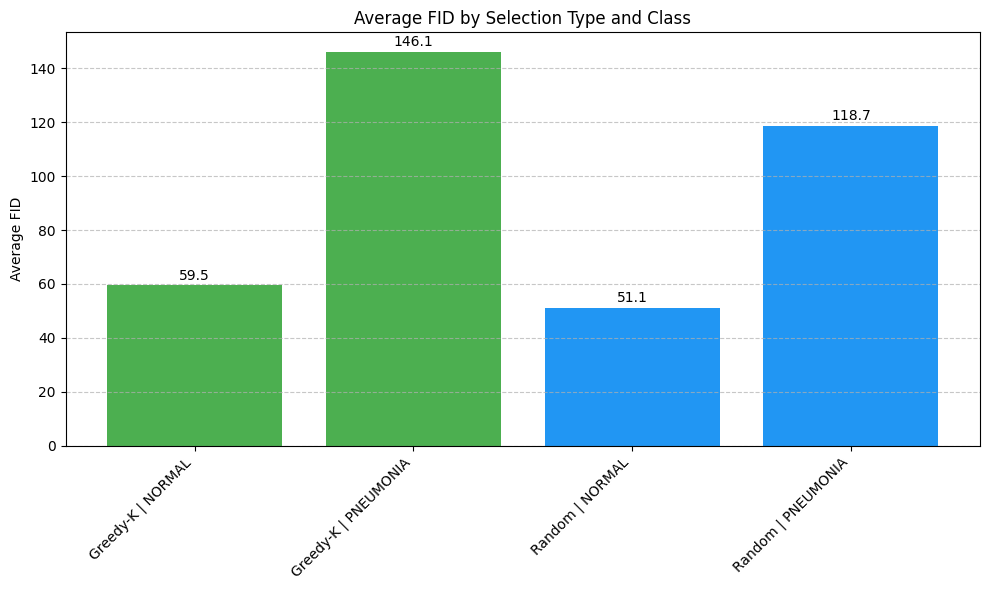

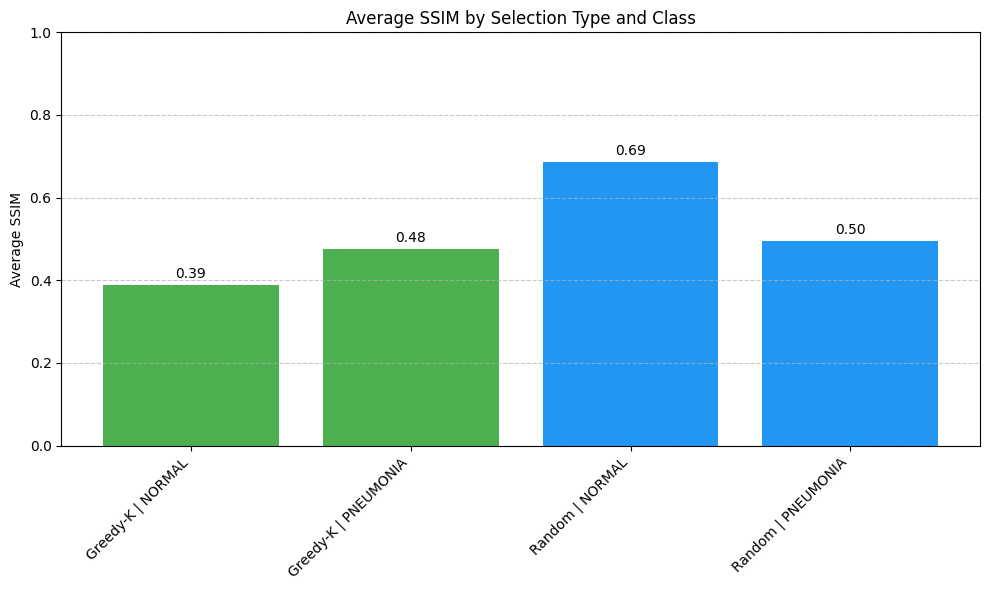

In [5]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Agrupar FID e SSIM por (tipo de seleção + classe)
fid_por_grupo = defaultdict(list)
ssim_por_grupo = defaultdict(list)

for r in results:
    config = r["configuração"]
    classe = r["classe"]
    fid = r["fid"]
    ssim = r["ssim"]

    # Extrair tipo de seleção
    _, metodo, _ = config.split("/")
    selecao_desc = "Greedy-K" if "Greedy" in metodo else "Random"

    chave = f"{selecao_desc} | {classe}"
    fid_por_grupo[chave].append(fid)
    ssim_por_grupo[chave].append(ssim)

# Mostrar médias no console
print("\n📊 MÉDIAS POR SELEÇÃO E CLASSE:")
print("================================")

grupos = []
medias_fid = []
medias_ssim = []

for chave in fid_por_grupo:
    media_fid = sum(fid_por_grupo[chave]) / len(fid_por_grupo[chave])
    media_ssim = sum(ssim_por_grupo[chave]) / len(ssim_por_grupo[chave])
    
    grupos.append(chave)
    medias_fid.append(media_fid)
    medias_ssim.append(media_ssim)
    
    print(f"🔹 {chave}")
    print(f"   AVG FID  : {media_fid:.4f}")
    print(f"   AVG SSIM : {media_ssim:.4f}")
    print("-" * 40)

# === GRÁFICO: FID
plt.figure(figsize=(10, 6))
colors = ["#4CAF50" if "Greedy" in g else "#2196F3" for g in grupos]
bars_fid = plt.bar(grupos, medias_fid, color=colors)

plt.title("Average FID by Selection Type and Class")
plt.ylabel("Average FID")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_fid:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# === GRÁFICO: SSIM
plt.figure(figsize=(10, 6))
bars_ssim = plt.bar(grupos, medias_ssim, color=colors)

plt.title("Average SSIM by Selection Type and Class")
plt.ylabel("Average SSIM")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_ssim:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


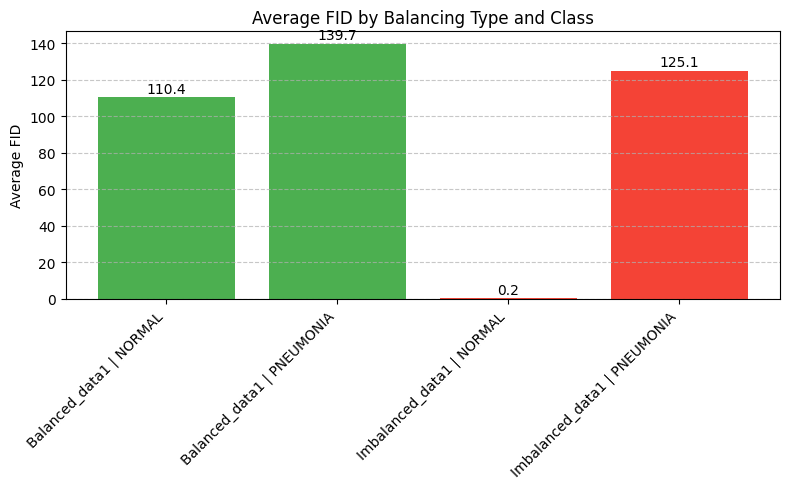

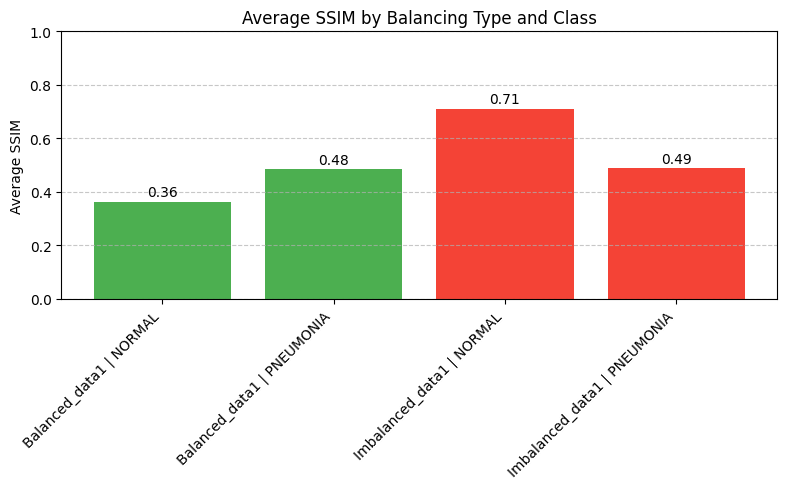

In [16]:
from collections import defaultdict
import matplotlib.pyplot as plt

# Group FID and SSIM by (balanceamento + classe)
fid_por_grupo = defaultdict(list)
ssim_por_grupo = defaultdict(list)

for r in results:
    config = r["configuração"]
    classe = r["classe"]
    fid = r["fid"]
    ssim = r["ssim"]

    # Extract balanceamento
    balanceamento, _, _ = config.split("/")
    chave = f"{balanceamento} | {classe}"

    fid_por_grupo[chave].append(fid)
    ssim_por_grupo[chave].append(ssim)

# Calcular médias
grupos = []
medias_fid = []
medias_ssim = []

for chave in fid_por_grupo:
    media_fid = sum(fid_por_grupo[chave]) / len(fid_por_grupo[chave])
    media_ssim = sum(ssim_por_grupo[chave]) / len(ssim_por_grupo[chave])
    
    grupos.append(chave)
    medias_fid.append(media_fid)
    medias_ssim.append(media_ssim)

# === GRÁFICO FID ===
plt.figure(figsize=(8, 5))
bars_fid = plt.bar(grupos, medias_fid, color=["#4CAF50" if "Balanced" in g else "#F44336" for g in grupos])
plt.title("Average FID by Balancing Type and Class")
plt.ylabel("Average FID")
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_fid:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# === GRÁFICO SSIM ===
plt.figure(figsize=(8, 5))
bars_ssim = plt.bar(grupos, medias_ssim, color=["#4CAF50" if "Balanced" in g else "#F44336" for g in grupos])
plt.title("Average SSIM by Balancing Type and Class")
plt.ylabel("Average SSIM")
plt.ylim(0, 1.0)
plt.xticks(rotation=45, ha="right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_ssim:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()
